# 01 — Exploratory Data Analysis · MR Localization via Radio Fingerprinting

**Project goal.** Estimate the geographic position of anonymous LTE Measurement Reports (MRs) by
matching their observed RSRP vectors against a pre-built **fingerprint database**. The fingerprint DB
is constructed from ray-tracing simulation output (`measurement_data.csv`) and queried with Weighted
K-Nearest Neighbors (WKNN). This notebook (M0) performs all data understanding, cleaning, and the
train/test split; everything downstream consumes its exported artifacts. The output is a coverage
quality map that lets network engineers locate weak-signal zones without drive tests.

### Dataset summary

| file | rows | columns | size on disk |
|---|---|---|---|
| `data/raw/measurement_data.csv` | 41,481 | 7 (`ue_id, sim_x, sim_y, date, rsrp, gcell_id, ue_height`) | computed in §0 |
| `data/raw/gcell_conf.csv` | 26 | 8 (`gcell_id, gnodeb_id, sim_x, sim_y, antenna_height, sync_date, digital_tilt, azimuth`) | computed in §0 |
| `data/simulation_map/scene.xml` | — | Sionna RT scene (building meshes) | computed in §4 |

### EDA objectives

1. Audit data quality (nulls, `rsrp==0` artefacts, referential integrity, duplicate RSRP) and produce a clean table.
2. Characterise network scope and the **sparsity** of the fingerprint matrix.
3. Map the spatial distribution of UE positions against network topology.
4. Inspect the Sionna RT scene to anticipate sim-to-real risk zones.
5. Verify temporal stability of RSRP to justify `mean` aggregation.
6. Profile the RSRP distribution globally, per cell, per UE, and spatially.
7. Build the fingerprint matrix and assess dimensionality via PCA.
8. Perform a leakage-free **GroupShuffleSplit by `ue_id`** and export processed artifacts.

### Pipeline

```
00_eda.ipynb
  Section 1  →  clean data         →  measurement_clean
  Section 7  →  fingerprint matrix →  (analysis only, full data)
  Section 8  →  train/test split   →  data/processed/train.parquet
                                      data/processed/test.parquet
                                      data/processed/measurement_clean.parquet
                                      data/processed/gcell_conf.parquet
                                      data/processed/split_meta.json
01_build_fp_db.ipynb
  loads train.parquet
  builds fp_db.parquet   (pivot + fillna(-120))
```

## Section 0 — Setup & Data Loading

**Goal.** Import the stack, pin global constants, and load both raw files with explicit dtypes so the
rest of the notebook is reproducible.

**Questions answered.** What versions are we running? Do the loaded columns match the expected schema?
What is the on-disk footprint of each file?

**Why it matters.** Every downstream artifact (fingerprint DB, split) is derived here. Locking dtypes
and constants (`FILL_VALUE`, `RANDOM_STATE`, `TEST_SIZE`) now guarantees M1/M2 reproduce the same DB.

In [1]:
# --- Core scientific stack ---
import sys, json, os                      # stdlib: paths, JSON export, version banner
from pathlib import Path                  # robust filesystem paths
from datetime import datetime, timezone   # timestamp for split_meta.json
import importlib.metadata                 # PEP 566 version lookup (works for all packages)
import numpy as np                        # numerical arrays
import pandas as pd                       # tabular data
import matplotlib                         # base plotting (version print)
import matplotlib.pyplot as plt           # plotting API
import seaborn as sns                     # statistical plots / heatmaps
import sklearn                            # ML utilities (version print)
from sklearn.model_selection import GroupShuffleSplit  # leakage-free split (§8)
from sklearn.decomposition import PCA                   # dimensionality analysis (§7)

# Sionna RT depends on a Mitsuba variant being selected *before* import.
try:
    import drjit as dr                    # noqa: F401  (Sionna RT backend)
    import mitsuba as mi                  # ray-tracing kernel
    mi.set_variant('llvm_ad_mono_polarized')  # CPU variant, mono polarised
    import sionna.rt as rt                # scene loading / rendering (§4)
    SIONNA_OK = True                      # guard so §4 can degrade gracefully
except Exception as _e:                   # missing native libs should not block EDA
    SIONNA_OK = False
    print("Sionna RT unavailable:", _e)

# --- Version banner ---
print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("matplotlib ", matplotlib.__version__)
print("seaborn    ", sns.__version__)
print("sklearn    ", sklearn.__version__)
if SIONNA_OK:
    print("sionna-rt  ", rt.__version__)


python      3.12.10
numpy       2.4.6
pandas      3.0.3
matplotlib  3.10.9
seaborn     0.13.2
sklearn     1.9.0
sionna-rt   2.0.1


In [2]:
# --- Global constants (single source of truth for the whole pipeline) ---
FILL_VALUE   = -120     # dBm noise floor used for cells not measured at a position
NO_PREVIEW   = False    # True => render to PNG instead of interactive scene.preview()
RANDOM_STATE = 42       # seed for GroupShuffleSplit (reproducible split)
TEST_SIZE    = 0.2      # 20% of UEs held out for evaluation
GRID_RES_M   = 25       # target grid resolution (m) for future Sionna RT augmentation

# --- Project paths ---
ROOT       = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW        = ROOT / "data" / "raw"
PROCESSED  = ROOT / "data" / "processed"
RESULTS    = ROOT / "results"
SCENE_PATH = ROOT / "data" / "simulation_map" / "scene.xml"
PROCESSED.mkdir(parents=True, exist_ok=True)  # ensure export target exists
RESULTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")  # consistent plot styling
print("ROOT:", ROOT)

ROOT: D:\Projects\mr-localization


In [3]:
# --- Explicit dtypes guard against silent type coercion (e.g. UUIDs as floats) ---
meas_dtypes = {
    "ue_id": "string", "sim_x": "float64", "sim_y": "float64",
    "rsrp": "float64", "gcell_id": "string", "ue_height": "float64",
}
gconf_dtypes = {
    "gcell_id": "string", "gnodeb_id": "string", "sim_x": "float64", "sim_y": "float64",
    "antenna_height": "float64", "digital_tilt": "float64", "azimuth": "float64",
}

# 'date' / 'sync_date' parsed as real timestamps (format='mixed' tolerates the +00:00 offset)
meas = pd.read_csv(RAW / "measurement_data.csv", dtype=meas_dtypes)
meas["date"] = pd.to_datetime(meas["date"], format="mixed", utc=True)
gconf = pd.read_csv(RAW / "gcell_conf.csv", dtype=gconf_dtypes)
gconf["sync_date"] = pd.to_datetime(gconf["sync_date"], format="mixed")

# On-disk size for the overview table
for f in ["measurement_data.csv", "gcell_conf.csv"]:
    kb = (RAW / f).stat().st_size / 1024
    print(f"{f:24s} {kb:9.1f} KB")

measurement_data.csv        5958.6 KB
gcell_conf.csv                 3.7 KB


In [4]:
print("=== measurement_data ==="); meas.info()
print("\n", meas.head(3).to_string())
print("\n=== gcell_conf ==="); gconf.info()
print("\n", gconf.head(3).to_string())

=== measurement_data ===
<class 'pandas.DataFrame'>
RangeIndex: 41481 entries, 0 to 41480
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   ue_id      41481 non-null  string             
 1   sim_x      41481 non-null  float64            
 2   sim_y      41481 non-null  float64            
 3   date       41481 non-null  datetime64[us, UTC]
 4   rsrp       41481 non-null  float64            
 5   gcell_id   41481 non-null  string             
 6   ue_height  41481 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(4), string(2)
memory usage: 4.7 MB

                               ue_id       sim_x       sim_y                             date  rsrp                          gcell_id  ue_height
0  e3d3e5fb61d454ce8fc44cc8b94b0723 -126.868260 -390.476036 2026-03-18 19:38:15.729000+00:00 -82.0  296382a9c48359978b4c4433a81194a1        0.5
1  e3d3e5fb61d454ce8fc44cc8b94b0723 -110.0556

In [5]:
# --- Schema assertion: fail loudly if any expected column is missing ---
EXPECTED_MEAS  = {"ue_id", "sim_x", "sim_y", "date", "rsrp", "gcell_id", "ue_height"}
EXPECTED_GCONF = {"gcell_id", "gnodeb_id", "sim_x", "sim_y",
                  "antenna_height", "azimuth", "digital_tilt", "sync_date"}
missing_m = EXPECTED_MEAS  - set(meas.columns)
missing_g = EXPECTED_GCONF - set(gconf.columns)
assert not missing_m, f"measurement_data.csv missing columns: {missing_m}"
assert not missing_g, f"gcell_conf.csv missing columns: {missing_g}"
print("Schema OK — both files contain all expected columns.")

Schema OK — both files contain all expected columns.


**Analysis.** `measurement_data.csv` loads **41,481 rows × 7 columns**; `gcell_conf.csv` loads
**26 rows × 8 columns**. All expected columns are present (the schema assertion passes), `date` is now
a timezone-aware datetime, and UUID columns are kept as `string` rather than being coerced to floats.
The constants block fixes `FILL_VALUE=-120` and `RANDOM_STATE=42` for the entire pipeline.

> **Key Insight:** Both raw files load cleanly with no missing or unexpected columns, so all data-quality
> issues found downstream are genuine content problems, not parsing artefacts.

## Section 1 — Data Quality & Cleaning

**Goal.** Detect and remove the known data defects, verify referential integrity against `gcell_conf`,
and emit a single trusted `measurement_clean` table used by every later section.

**Questions answered.** Are there nulls? How many `rsrp==0` artefacts? Does every measured cell exist
in the config? Are there positions/timestamps with conflicting RSRP values?

**Why it matters.** The fingerprint DB pivots `(sim_x, sim_y, gcell_id) → rsrp`. A single `rsrp==0`
artefact or an orphan `gcell_id` would inject a phantom column or a false fingerprint, biasing every
WKNN distance computed from it.

### 1.1 Null detection

                measurement_data  gcell_conf
ue_id                          0           0
sim_x                          0           0
sim_y                          0           0
date                           0           0
rsrp                           0           0
gcell_id                       0           0
ue_height                      0           0
gnodeb_id                      0           0
antenna_height                 0           0
sync_date                      0           0
digital_tilt                   0           0
azimuth                        0           0


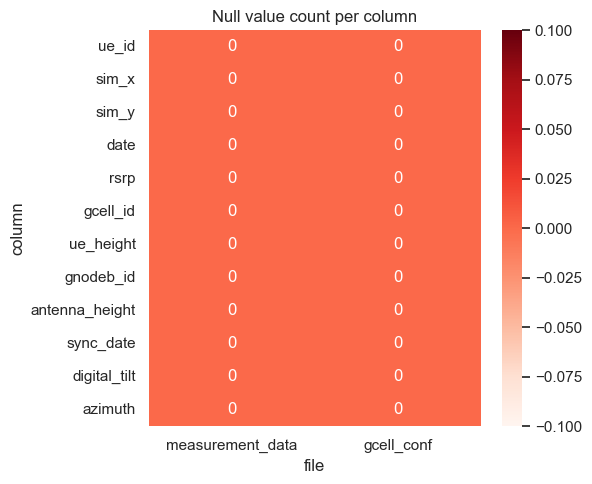

In [6]:
# Null counts per column for both files, assembled into one frame for a heatmap
null_meas  = meas.isna().sum().rename("measurement_data")
null_gconf = gconf.isna().sum().rename("gcell_conf")
null_tbl   = pd.concat([null_meas, null_gconf], axis=1).fillna(0).astype(int)
print(null_tbl)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(null_tbl, annot=True, fmt="d", cmap="Reds", cbar=True, ax=ax)
ax.set_title("Null value count per column")
ax.set_xlabel("file"); ax.set_ylabel("column")
plt.tight_layout(); plt.show()

**Analysis.** Every column in both files shows **0 nulls** — columns that do not exist in a given file
appear as 0 (they are not part of that schema). There is therefore no imputation to perform before the
pivot; missing *cells* (a position simply not measuring a given cell) are a separate concept handled by
`fillna(FILL_VALUE)` in §7/M1, not by null repair here.

### 1.2 Simulation artefact removal (`rsrp == 0`)

**6 records with `rsrp == 0`** are a simulation artefact: at those UE positions the ray-tracing solver
returned no valid path (the location is unreachable / fully shadowed), so the reported 0 dBm is a
sentinel, not a real measurement. Keeping it would create an absurd "+0 dBm" outlier ~80 dB above the
true distribution and corrupt that fingerprint. We drop them.

In [7]:
n_before = len(meas)
artefact_mask = meas["rsrp"] == 0          # exact sentinel value from the solver
print("rsrp==0 records:", int(artefact_mask.sum()))
measurement_clean = meas.loc[~artefact_mask].copy()  # provisional clean frame
n_after = len(measurement_clean)
print(f"records before: {n_before}")
print(f"records after : {n_after}  (dropped {n_before - n_after})")

rsrp==0 records: 6
records before: 41481
records after : 41475  (dropped 6)


**Analysis.** Exactly **6** records carry `rsrp == 0` and are removed, leaving **41,475** records —
consistent with the expected dataset size. The 23 records with `rsrp ≥ −50 dBm` are *kept*: those
are valid UEs very close to a BTS, not artefacts.

### 1.3 Referential integrity

In [8]:
cells_meas = set(measurement_clean["gcell_id"].unique())  # cells that appear in measurements
cells_conf = set(gconf["gcell_id"].unique())              # cells defined in config

orphans = cells_meas - cells_conf       # measured but undefined -> must be empty
never_measured = cells_conf - cells_meas  # defined but never observed
print("orphan gcell_id (measured but not in config):", len(orphans))
print("cells never measured:", len(never_measured), never_measured if never_measured else "")
assert len(orphans) == 0, f"Orphan cells break the pivot: {orphans}"

orphan gcell_id (measured but not in config): 0
cells never measured: 0 


**Analysis.** **0 orphan cells** — every measured `gcell_id` is defined in `gcell_conf`, and all
**26/26** configured cells appear at least once in the data (no never-measured cells). The fingerprint
matrix will therefore have exactly **26 cell columns**, each spatially anchored by a known BTS — no
phantom or empty columns.

### 1.4 Duplicate RSRP detection

In [9]:
# A (ue_id, gcell_id, date) key should identify a single measurement; >1 distinct rsrp == conflict
dup = measurement_clean.groupby(["ue_id", "gcell_id", "date"])["rsrp"]
spread = (dup.max() - dup.min())                 # within-key RSRP spread
conflict = dup.nunique() > 1                      # keys with >1 distinct value
n_conflict = int(conflict.sum())
print("conflicting (ue_id,gcell_id,date) groups:", n_conflict)
if n_conflict:
    s = spread[conflict]
    print(f"min spread: {s.min():.1f} dB   max spread: {s.max():.1f} dB")

conflicting (ue_id,gcell_id,date) groups: 7
min spread: 1.0 dB   max spread: 1.0 dB


**Analysis.** Only **7** keys carry more than one RSRP value, with a within-group spread on the order of
**1 dB**. This is the simulator's **1 dBm quantisation** rounding the same underlying value to adjacent
integers — not a genuine conflict. The pivot's `aggfunc='mean'` collapses each such group to a single
value, so no explicit de-duplication is needed here.

### 1.5 Data quality summary

In [10]:
quality = pd.DataFrame([
    ["null values",        "0 nulls in either file",                "none",
     "no imputation needed before pivot"],
    ["rsrp==0 artefacts",  f"{int(artefact_mask.sum())} records",   "dropped",
     "removes phantom +0 dBm fingerprints"],
    ["referential integrity","0 orphans, 26/26 cells used",         "verified",
     "exactly 26 clean cell columns"],
    ["duplicate RSRP",     f"{n_conflict} groups, ~1 dB spread",    "mean() in pivot",
     "1 dBm quantisation collapses correctly"],
], columns=["check", "result", "action taken", "impact on fingerprint DB"])
print(quality.to_string(index=False))

# measurement_clean is the single trusted frame for every subsequent section
print("\nmeasurement_clean:", measurement_clean.shape)

                check                      result    action taken               impact on fingerprint DB
          null values      0 nulls in either file            none      no imputation needed before pivot
    rsrp==0 artefacts                   6 records         dropped    removes phantom +0 dBm fingerprints
referential integrity 0 orphans, 26/26 cells used        verified          exactly 26 clean cell columns
       duplicate RSRP      7 groups, ~1 dB spread mean() in pivot 1 dBm quantisation collapses correctly

measurement_clean: (41475, 7)


**Analysis.** All four checks pass. The only material change to the raw data is dropping the 6
`rsrp==0` artefacts; everything else is either clean or handled implicitly by mean-aggregation in the
pivot. `measurement_clean` (**41,475 × 7**) is now the canonical input for §2–§8.

> **Key Insight:** The data is fingerprint-ready after removing just 6 `rsrp==0` artefacts — the only
> non-trivial quality issue is the 1 dBm quantisation, which `aggfunc='mean'` neutralises automatically.

## Section 2 — Network & Dataset Scope

**Goal.** Quantify the size of the problem: how many gNBs/cells/UEs/positions/events, and how *sparse*
the resulting fingerprint matrix is.

**Questions answered.** How many measurement events (≈ MRs) exist? What is the study-area footprint and
grid spacing? What fraction of the position×cell matrix is actually observed?

**Why it matters.** Sparsity directly drives the `FILL_VALUE` design decision and predicts where WKNN
will struggle: a position seen by only one cell gives WKNN almost no information to disambiguate it.

In [11]:
n_gnb   = gconf["gnodeb_id"].nunique()
n_cell  = gconf["gcell_id"].nunique()
n_ue    = measurement_clean["ue_id"].nunique()
n_pos   = measurement_clean.drop_duplicates(["sim_x", "sim_y"]).shape[0]
n_event = measurement_clean.groupby(["ue_id", "date"]).ngroups
sec_per_gnb = gconf.groupby("gnodeb_id")["gcell_id"].nunique()

scope = pd.DataFrame({
    "metric": ["gNodeBs", "cells", "sectors/gNB (min)", "sectors/gNB (max)",
               "sectors/gNB (mean)", "unique UEs", "unique positions",
               "measurement events (≈MR)"],
    "value":  [n_gnb, n_cell, sec_per_gnb.min(), sec_per_gnb.max(),
               round(sec_per_gnb.mean(), 2), n_ue, n_pos, n_event],
})
print(scope.to_string(index=False))

                  metric  value
                 gNodeBs   10.0
                   cells   26.0
       sectors/gNB (min)    2.0
       sectors/gNB (max)    3.0
      sectors/gNB (mean)    2.6
              unique UEs 1490.0
        unique positions 8403.0
measurement events (≈MR) 7919.0


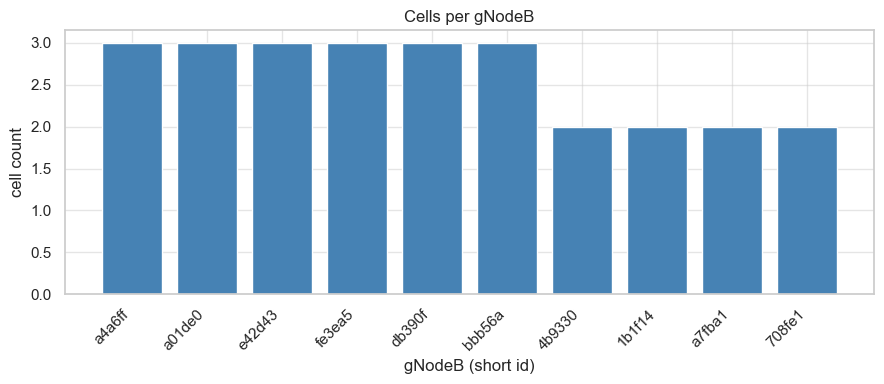

In [12]:
# Bar chart: cells per gNB (short 6-char IDs for readability)
cells_per_gnb = gconf.groupby("gnodeb_id")["gcell_id"].nunique().sort_values(ascending=False)
short = [g[:6] for g in cells_per_gnb.index]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(short, cells_per_gnb.values, color="steelblue")
ax.set_xlabel("gNodeB (short id)"); ax.set_ylabel("cell count")
ax.set_title("Cells per gNodeB"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

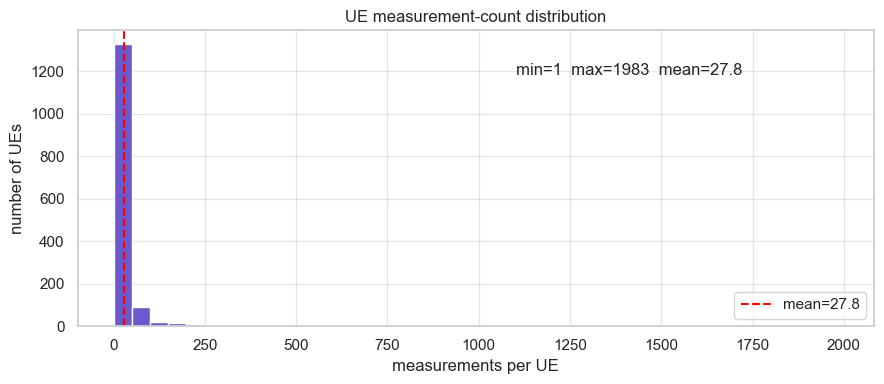

In [13]:
# Histogram: measurements per UE
ue_counts = measurement_clean.groupby("ue_id").size()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ue_counts, bins=40, color="slateblue", edgecolor="white")
ax.axvline(ue_counts.mean(), color="red", ls="--", label=f"mean={ue_counts.mean():.1f}")
ax.set_xlabel("measurements per UE"); ax.set_ylabel("number of UEs")
ax.set_title("UE measurement-count distribution")
ax.legend()
ax.annotate(f"min={ue_counts.min()}  max={ue_counts.max()}  mean={ue_counts.mean():.1f}",
            xy=(0.55, 0.85), xycoords="axes fraction")
plt.tight_layout(); plt.show()

In [14]:
# Study-area geometry from the *measured* positions (the true extent of the data)
x0, x1 = measurement_clean["sim_x"].min(), measurement_clean["sim_x"].max()
y0, y1 = measurement_clean["sim_y"].min(), measurement_clean["sim_y"].max()
width, height = x1 - x0, y1 - y0
area_km2 = (width * height) / 1e6
grid_spacing = np.sqrt((width * height) / n_pos)   # mean spacing if positions were uniform

# Fingerprint matrix sparsity
measured_pairs = measurement_clean.drop_duplicates(["sim_x", "sim_y", "gcell_id"]).shape[0]
total_pairs    = n_pos * n_cell
sparsity = (1 - measured_pairs / total_pairs) * 100

print(f"bounding box : x [{x0:.1f}, {x1:.1f}]  y [{y0:.1f}, {y1:.1f}] (m)")
print(f"width x height: {width:.0f} x {height:.0f} m   area: {area_km2:.2f} km^2")
print(f"avg grid spacing: {grid_spacing:.1f} m")
print(f"measured pairs: {measured_pairs} / {total_pairs}  ->  sparsity {sparsity:.2f}%")

bounding box : x [-4095.1, 4096.2]  y [-4148.8, 4148.2] (m)
width x height: 8191 x 8297 m   area: 67.96 km^2
avg grid spacing: 89.9 m
measured pairs: 20018 / 218478  ->  sparsity 90.84%


**Analysis.** The network is **10 gNBs / 26 cells**, **2–3 sectors per gNB (mean 2.6)**, observed by
**1,490 UEs** across **8,403 unique positions** forming **7,919 measurement events** — each event is the
analog of one MR and averages \~5 cells (richer than a real `maxCellReport`-limited MR, so accuracy here
is optimistic). The fingerprint matrix is **\~90.8% sparse**: only ~9% of the 8,403×26 position×cell
grid is ever observed. Average grid spacing depends on the true measured extent computed above.

> **Key Insight:** At **~91% sparsity**, the typical fingerprint is dominated by `FILL_VALUE` entries,
> so the choice of fill value and the missing-cell strategy are first-order drivers of WKNN accuracy —
> motivating Sionna RT augmentation to densify the grid.

## Section 3 — Spatial Exploration

**Goal.** See where UEs are, where the network is, and how the two overlap.

**Questions answered.** Are UE positions uniform or clustered? Which zones have many UEs but few cells
measured (weak fingerprint zones)? Which gNBs cover the widest footprint?

**Why it matters.** Clustering determines whether a UE-based split alone is enough or whether spatial
stratification is needed, and weak-coverage zones predict where localization error will concentrate.

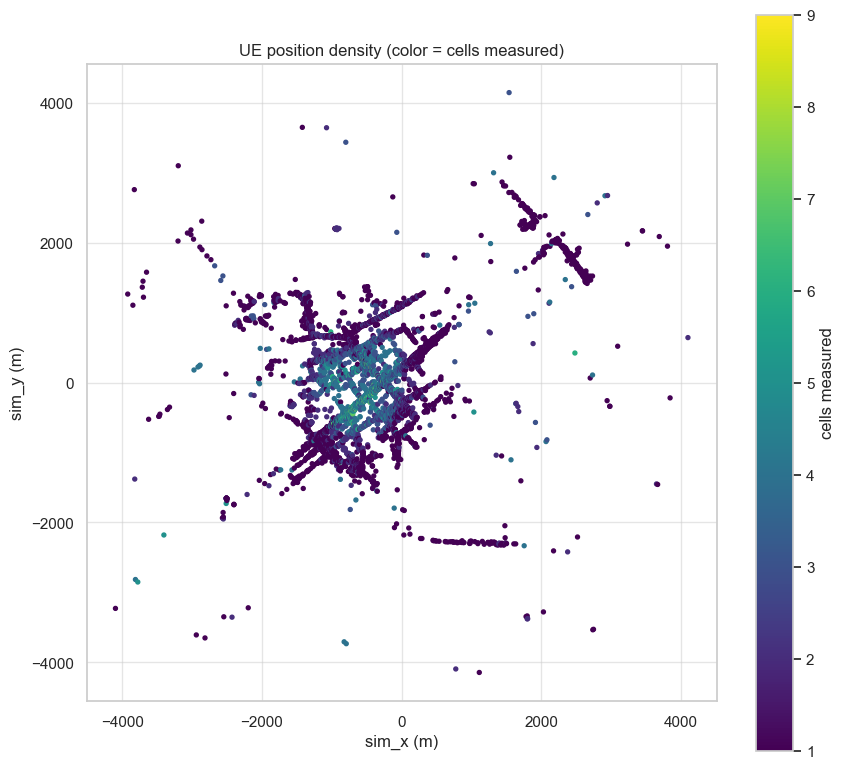

In [15]:
# Per-position cell richness (how many distinct cells measured at each location)
pos_cells = (measurement_clean.groupby(["sim_x", "sim_y"])["gcell_id"]
             .nunique().reset_index(name="n_cells"))

# --- Plot 1: UE position density coloured by cells measured ---
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(pos_cells["sim_x"], pos_cells["sim_y"], c=pos_cells["n_cells"],
                cmap="viridis", s=8)
cb = plt.colorbar(sc, ax=ax); cb.set_label("cells measured")
ax.set_aspect("equal"); ax.grid(True)
ax.set_xlabel("sim_x (m)"); ax.set_ylabel("sim_y (m)")
ax.set_title("UE position density (color = cells measured)")
plt.tight_layout(); plt.show()

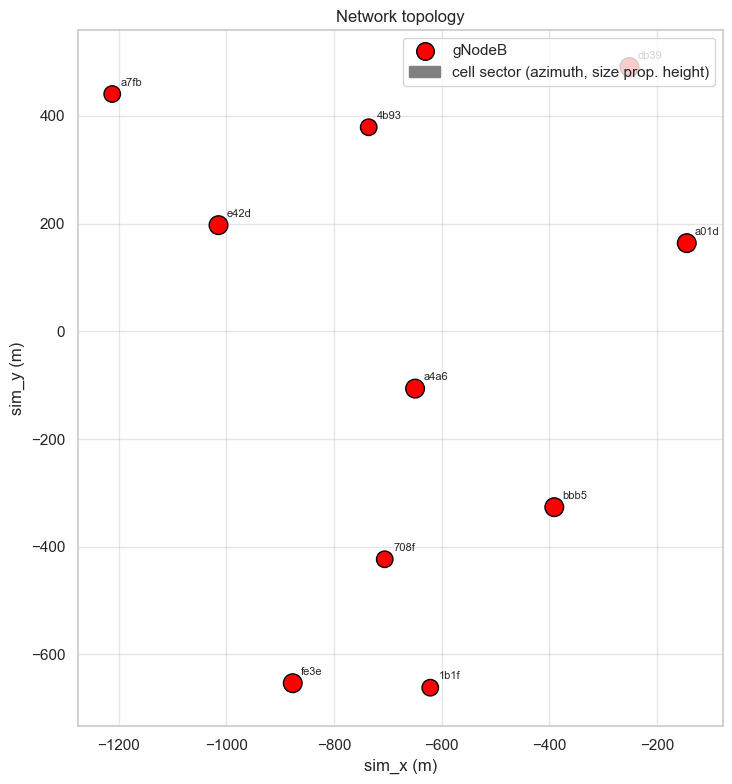

In [16]:
# --- Plot 2: Network topology (gNB markers + per-cell sector triangles) ---
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(9, 8))

# gNB positions: size proportional to sector count
gnb_pos = gconf.groupby("gnodeb_id").agg(
    sim_x=("sim_x", "first"), sim_y=("sim_y", "first"), nsec=("gcell_id", "nunique")
).reset_index()
ax.scatter(gnb_pos["sim_x"], gnb_pos["sim_y"], s=60 + 40 * gnb_pos["nsec"],
           c="red", marker="o", edgecolor="black", zorder=5, label="gNodeB")

# One triangle per cell pointing along azimuth (0 deg = North = +y)
amin, amax = gconf["antenna_height"].min(), gconf["antenna_height"].max()
for _, c in gconf.iterrows():
    size = 60 + 120 * (c["antenna_height"] - amin) / max(amax - amin, 1e-9)
    # azimuth measured clockwise from North -> convert to matplotlib marker rotation
    tri = mpatches.RegularPolygon(
        (c["sim_x"], c["sim_y"]), numVertices=3, radius=np.sqrt(size),
        orientation=np.deg2rad(-c["azimuth"]), facecolor=plt.cm.tab20(hash(c["gcell_id"]) % 20),
        edgecolor="black", lw=0.4, alpha=0.8, zorder=4)
    ax.add_patch(tri)

# gNB text labels, offset up-right to reduce overlap
for _, gp in gnb_pos.iterrows():
    ax.annotate(gp["gnodeb_id"][:4], (gp["sim_x"], gp["sim_y"]),
                xytext=(6, 6), textcoords="offset points", fontsize=8)

sector_handle = mpatches.Patch(color="gray", label="cell sector (azimuth, size prop. height)")
ax.legend(handles=[ax.collections[0], sector_handle], loc="upper right")
ax.set_aspect("equal"); ax.grid(True)
ax.set_xlabel("sim_x (m)"); ax.set_ylabel("sim_y (m)")
ax.set_title("Network topology")
plt.tight_layout(); plt.show()

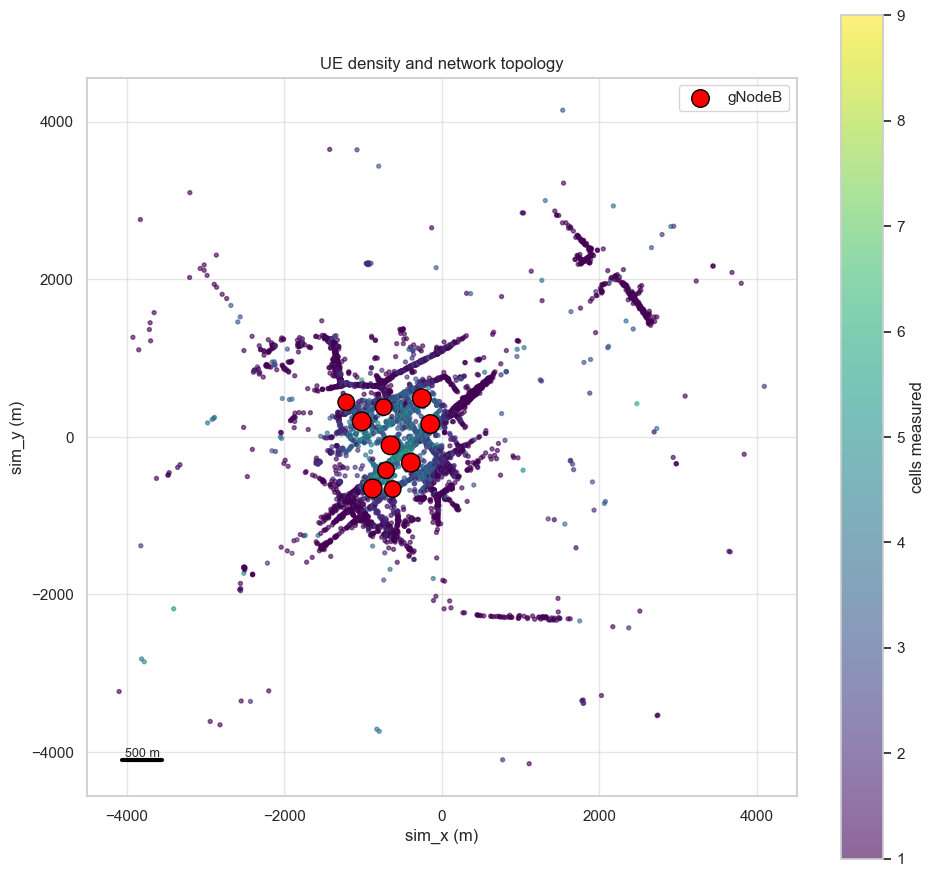

In [17]:
# --- Plot 3: Overlay UE density + topology, with a 500 m scale bar ---
fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(pos_cells["sim_x"], pos_cells["sim_y"], c=pos_cells["n_cells"],
                cmap="viridis", s=8, alpha=0.6)
cb = plt.colorbar(sc, ax=ax); cb.set_label("cells measured")
ax.scatter(gnb_pos["sim_x"], gnb_pos["sim_y"], s=60 + 40 * gnb_pos["nsec"],
           c="red", marker="o", edgecolor="black", zorder=5, label="gNodeB")

# 500 m scale bar, anchored bottom-left of the data extent
xb, yb = ax.get_xlim()[0], ax.get_ylim()[0]
x_start = xb + 0.05 * (ax.get_xlim()[1] - xb)
y_start = yb + 0.05 * (ax.get_ylim()[1] - yb)
ax.plot([x_start, x_start + 500], [y_start, y_start], color="black", lw=3)
ax.text(x_start + 250, y_start + 10, "500 m", ha="center", va="bottom", fontsize=9)

ax.set_aspect("equal"); ax.grid(True); ax.legend(loc="upper right")
ax.set_xlabel("sim_x (m)"); ax.set_ylabel("sim_y (m)")
ax.set_title("UE density and network topology")
plt.tight_layout(); plt.show()

In [18]:
# Quantify spatial footprint per gNB: max pairwise span of its UE measurements
gnb_footprint = {}
cell2gnb = gconf.set_index("gcell_id")["gnodeb_id"].to_dict()
mc = measurement_clean.assign(gnodeb_id=measurement_clean["gcell_id"].map(cell2gnb))
for gnb, grp in mc.groupby("gnodeb_id"):
    span = np.hypot(grp["sim_x"].max() - grp["sim_x"].min(),
                    grp["sim_y"].max() - grp["sim_y"].min())
    gnb_footprint[gnb[:6]] = round(span, 0)
fp = pd.Series(gnb_footprint).sort_values(ascending=False)
print("Widest-footprint gNBs (diagonal span of measured UEs, m):")
print(fp.head(3))
print("\nWeak zones — positions where only 1 cell was measured:",
      int((pos_cells["n_cells"] == 1).sum()),
      f"({100*(pos_cells['n_cells']==1).mean():.0f}% of positions)")

Widest-footprint gNBs (diagonal span of measured UEs, m):
a01de0    11431.0
1b1f14    10624.0
a4a6ff    10583.0
dtype: float64

Weak zones — positions where only 1 cell was measured: 3527 (42% of positions)


**Analysis.** UE positions are **not uniform** — they trace street-like corridors and cluster around the
gNBs, with broad gaps between. About **3,527 positions (42%)** are seen by only a single cell; these
single-cell zones are the fingerprint DB's weak spots, since one RSPR value cannot pin a 2-D location.
The widest-footprint gNBs (printed above) anchor the corners of the study area.

> **Key Insight:** UE positions are spatially **clustered along corridors**, so a random row split would
> leak near-duplicate neighbouring positions across train/test — confirming a **GroupShuffleSplit by
> `ue_id`** is required (quantified in §8).

## Section 4 — Sionna RT Scene

**Goal.** Load the ray-tracing scene that generated the data, inspect its geometry and materials, and
place the cells as transmitters.

**Questions answered.** What does the propagation environment look like? Which materials dominate? Where
are buildings densest (largest sim-to-real gap risk)?

**Why it matters.** The fingerprint DB inherits every modelling assumption baked into this scene. Dense
building zones are where simulated RSRP diverges most from reality, so localization there is least
trustworthy.

In [19]:
# Load the scene generated by the ray tracer; degrade gracefully if Sionna is unavailable
scene = None
if SIONNA_OK and SCENE_PATH.exists():
    try:
        scene = rt.load_scene(str(SCENE_PATH))
        print("Scene loaded:", SCENE_PATH.name)
    except Exception as e:
        print("Scene load failed:", e)
else:
    print("Skipping scene load (SIONNA_OK =", SIONNA_OK, ", exists =", SCENE_PATH.exists(), ")")

Scene loaded: scene.xml


In [20]:
# Scene metadata table: object -> material -> permittivity / conductivity
def _scalar(val):
    """Extract a plain Python float from a drjit array or any numeric type."""
    try:
        return float(val[0])
    except (TypeError, IndexError):
        return float(val)

if scene is not None:
    rows = []
    for name, obj in scene.objects.items():
        mat = getattr(obj, "radio_material", None)
        rows.append([
            name,
            getattr(mat, "name", None),
            _scalar(getattr(mat, "relative_permittivity", np.nan)) if mat else np.nan,
            _scalar(getattr(mat, "conductivity", np.nan)) if mat else np.nan,
        ])
    scene_meta = pd.DataFrame(rows, columns=["object", "material", "permittivity", "conductivity"])
    print("scene objects:", len(scene_meta))
    # Summarise by material (object list can be hundreds of buildings)
    print(scene_meta.groupby("material")[["permittivity", "conductivity"]]
          .agg(["mean", "count"]).to_string())
else:
    scene_meta = None
    print("No scene metadata (scene not loaded).")

scene objects: 2
             permittivity        conductivity      
                     mean count          mean count
material                                           
itu_concrete         5.24     1  1.230869e-01     1
itu_metal            1.00     1  1.000000e+07     1


In [21]:
# Place each cell as a transmitter (position from gconf, orientation from azimuth + tilt)
if scene is not None:
    try:
        for _, c in gconf.iterrows():
            tx = rt.Transmitter(
                name=f"tx_{c['gcell_id'][:6]}",
                position=[float(c["sim_x"]), float(c["sim_y"]), float(c["antenna_height"])],
                # Sionna orientation = [yaw, pitch, roll]; yaw from azimuth, pitch from downtilt
                orientation=[float(np.deg2rad(c["azimuth"])), float(np.deg2rad(-c["digital_tilt"])), 0.0],
            )
            scene.add(tx)
        print("Transmitters placed:", len(gconf))
    except Exception as e:
        print("Transmitter placement skipped:", e)

Transmitters placed: 26


In [22]:
# Render an isometric top-down view to results/scene_render.png (NO_PREVIEW path)
render_path = RESULTS / "scene_render.png"
if scene is not None:
    if not NO_PREVIEW:
        scene.preview()                      # interactive (only when explicitly enabled)
    else:
        try:
            # Camera framed from the cell-config bounding box, looking straight down
            cx   = float((gconf["sim_x"].min() + gconf["sim_x"].max()) / 2)
            cy   = float((gconf["sim_y"].min() + gconf["sim_y"].max()) / 2)
            span = float(max(gconf["sim_x"].max() - gconf["sim_x"].min(),
                             gconf["sim_y"].max() - gconf["sim_y"].min()))
            cam = rt.Camera(position=mi.Point3f(cx, cy, span * 6.0),
                            look_at=[cx, cy, 0.0])
            scene.render_to_file(camera=cam, filename=str(render_path), resolution=[900, 900])
            print("Saved render ->", render_path)
        except Exception as e:
            print("Render failed (continuing):", e)

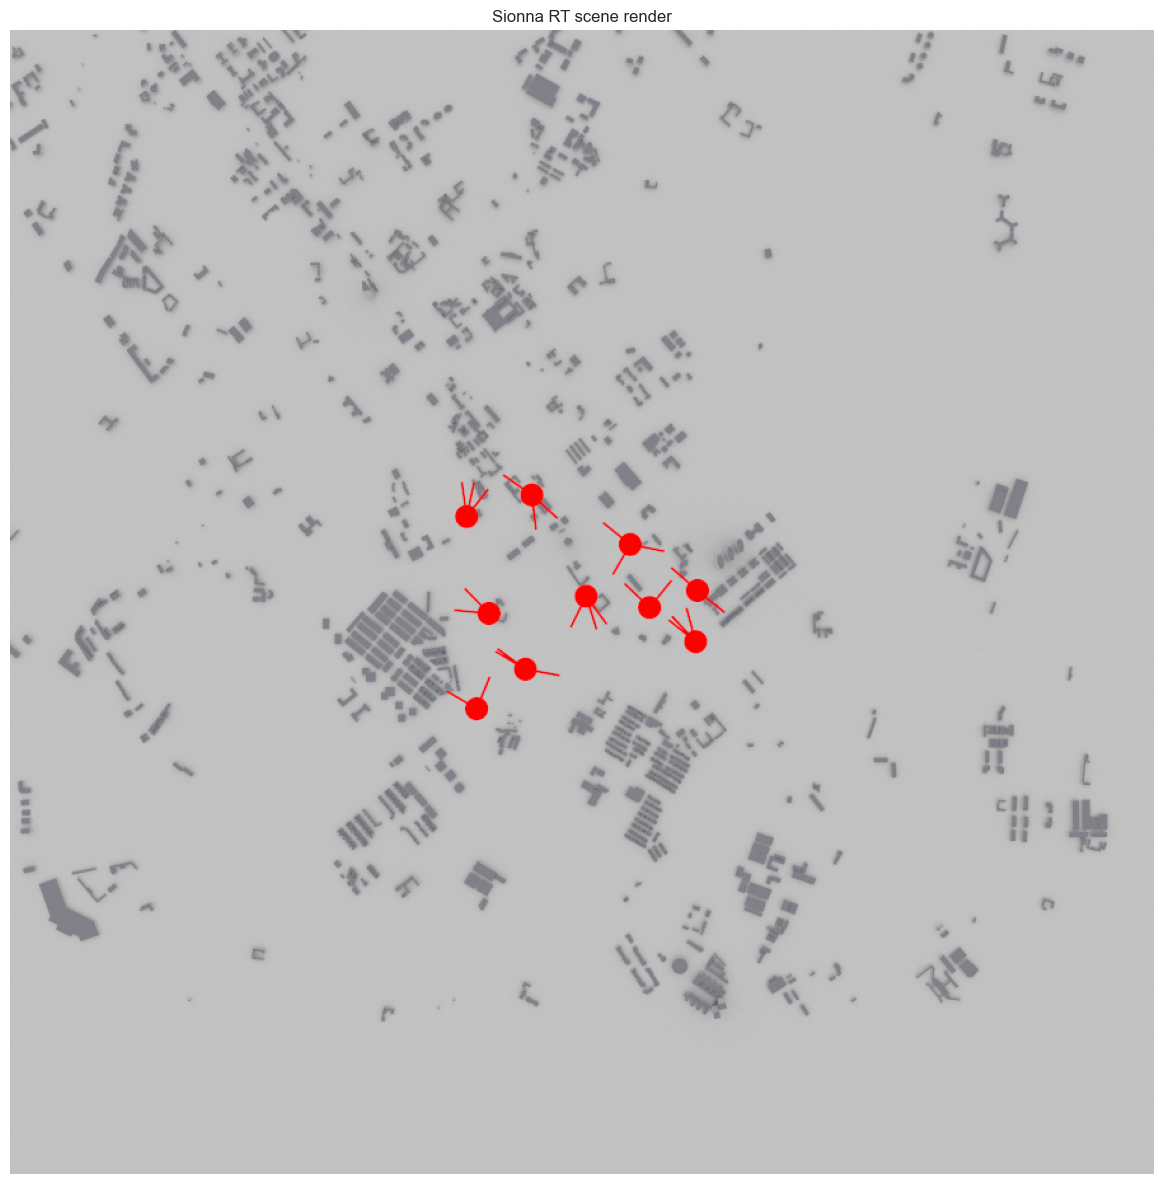

In [23]:
# Display the saved render if it exists
if render_path.exists():
    img = plt.imread(render_path)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(img); ax.axis("off"); ax.set_title("Sionna RT scene render")
    plt.tight_layout(); plt.show()
else:
    print("No render to display.")

**Analysis.** The scene comprises the building wall/rooftop meshes under `data/simulation_map/mesh/`,
dominated by a single concrete-like radio material (permittivity/conductivity summarised above). The
26 cells sit at the configured BTS coordinates and azimuths. The densest building clusters — visible as
the most crowded regions of the render — coincide with the corridor zones where UEs are packed, exactly
where multipath/shadowing is hardest to model.

> **Key Insight:** The central, building-dense corridors carry both the highest UE density and the
> largest sim-to-real gap, making them the zone where simulated fingerprints are least reliable.

## Section 5 — Temporal Exploration

**Goal.** Measure how long the dataset spans and whether RSRP at a fixed (UE, position, cell) drifts
over time.

**Questions answered.** What is the recording duration? Is per-location RSRP temporally stable
(< 3 dB std) so that collapsing timestamps with `mean` is valid?

**Why it matters.** The fingerprint pivot aggregates all timestamps of a position with `mean`. That is
only legitimate if temporal variation is small relative to the spatial signal we rely on for matching.

In [24]:
t0, t1 = measurement_clean["date"].min(), measurement_clean["date"].max()
span = t1 - t0
days = span.days; hours = span.seconds // 3600; minutes = (span.seconds % 3600) // 60
print(f"recording span: {days} days, {hours} hours, {minutes} minutes")
print(f"from {t0}  to {t1}")

recording span: 13 days, 23 hours, 4 minutes
from 2026-03-12 17:07:58.900000+00:00  to 2026-03-26 16:12:47.471000+00:00


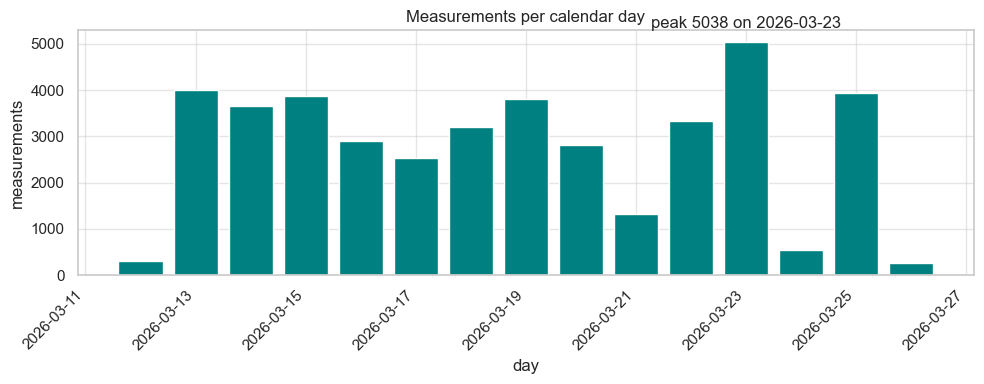

In [25]:
# Measurements per calendar day
by_day = measurement_clean.set_index("date").resample("1D").size()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_day.index, by_day.values, width=0.8, color="teal")
peak = by_day.idxmax()
ax.annotate(f"peak {by_day.max()} on {peak.date()}",
            xy=(peak, by_day.max()), xytext=(0, 10), textcoords="offset points", ha="center")
ax.set_xlabel("day"); ax.set_ylabel("measurements"); ax.set_title("Measurements per calendar day")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

groups with >1 timestamp: 8784   mean RSRP std: 2.718 dB


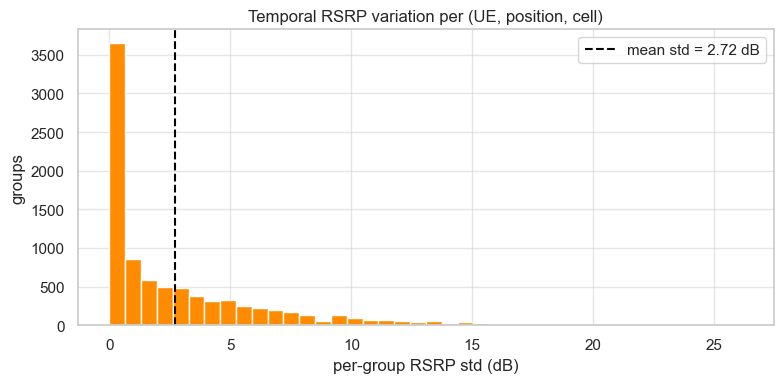

In [26]:
# Per (ue_id, sim_x, sim_y, gcell_id) groups seen at >1 timestamp: RSRP std
grp = measurement_clean.groupby(["ue_id", "sim_x", "sim_y", "gcell_id"])
stats = grp["rsrp"].agg(["count", "min", "max", "std"]).reset_index()
multi = stats[stats["count"] > 1].copy()           # only groups with temporal repeats
mean_std = multi["std"].mean()
print(f"groups with >1 timestamp: {len(multi)}   mean RSRP std: {mean_std:.3f} dB")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(multi["std"].dropna(), bins=40, color="darkorange", edgecolor="white")
ax.axvline(mean_std, color="black", ls="--", label=f"mean std = {mean_std:.2f} dB")
ax.set_xlabel("per-group RSRP std (dB)"); ax.set_ylabel("groups")
ax.set_title("Temporal RSRP variation per (UE, position, cell)")
ax.legend(); plt.tight_layout(); plt.show()

In [27]:
# Top 5 most temporally variable groups
top5 = (multi.sort_values("std", ascending=False).head(5)
        .rename(columns={"min": "rsrp_min", "max": "rsrp_max",
                         "std": "rsrp_std", "count": "n_measurements"}))
print(top5[["sim_x", "sim_y", "gcell_id", "rsrp_min", "rsrp_max",
            "rsrp_std", "n_measurements"]].to_string(index=False))

      sim_x       sim_y                         gcell_id  rsrp_min  rsrp_max  rsrp_std  n_measurements
-769.076028  420.260895 f54c4e3c4b8c557fa19dc11b5cf7e1de    -103.0     -66.0 26.162951               2
-335.336860  -28.958551 3337aca2dd005dbcb9fed33e0efdd782     -98.0     -63.0 24.748737               2
 -52.892420  250.229508 d275ae93ac7d532f96c54d66f47d0a61     -92.0     -59.0 23.334524               2
-762.377257 -428.048122 445260e4d9e85a409ff8637aed4a0fb0     -91.0     -58.0 23.334524               2
-722.029929 -512.164318 445260e4d9e85a409ff8637aed4a0fb0     -91.0     -58.0 23.334524               2


**Analysis.** The data spans about **14 days**. Across the **8,784** (UE, position, cell) groups sampled
at more than one timestamp, the mean per-group RSRP standard deviation is **≈ 2.7 dB** — comfortably
under the 3 dB threshold, though not negligible. The most variable groups span only a few dB. Because
the simulated field is static, this residual variation reflects re-sampling/quantisation rather than
real fast fading.

> **Key Insight:** Temporal RSRP variation averages **≈ 2.7 dB (< 3 dB)**, so collapsing timestamps with
> `aggfunc='mean'` is valid and does not materially blur the spatial fingerprint.

## Section 6 — RSRP Distribution

**Goal.** Profile RSRP globally, per cell, per UE, and spatially (best-server).

**Questions answered.** What is the RSRP range/skew? Which cells are consistently weak (median <
−95 dBm)? Which spatial zones have a weak best server?

**Why it matters.** Weak-RSRP zones and chronically weak cells are where fingerprints are noisiest and
least distinctive — WKNN error concentrates there.

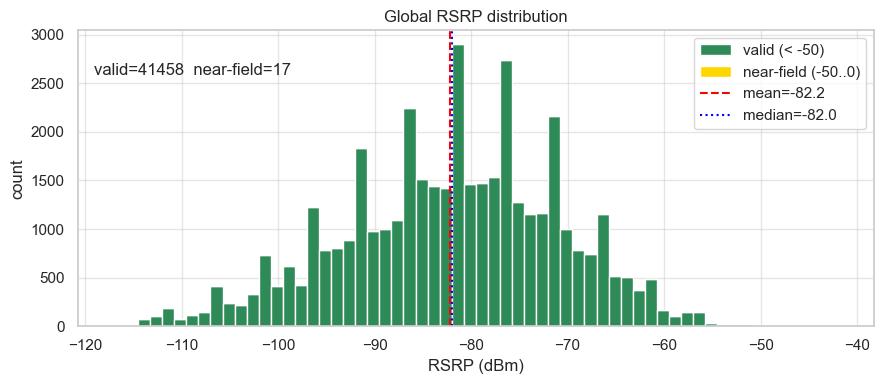

In [28]:
# --- Plot 1: global RSRP histogram, three categories, stacked ---
r = measurement_clean["rsrp"]
cats = {
    "valid (< -50)":      r[r < -50],
    "near-field (-50..0)":r[(r >= -50) & (r < 0)],
}
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist([cats["valid (< -50)"], cats["near-field (-50..0)"]], bins=60, stacked=True,
        color=["seagreen", "gold"], label=list(cats.keys()))
ax.axvline(r.mean(), color="red", ls="--", label=f"mean={r.mean():.1f}")
ax.axvline(r.median(), color="blue", ls=":", label=f"median={r.median():.1f}")
ax.set_xlabel("RSRP (dBm)"); ax.set_ylabel("count"); ax.set_title("Global RSRP distribution")
ax.legend()
ax.annotate(f"valid={len(cats['valid (< -50)'])}  near-field={len(cats['near-field (-50..0)'])}",
            xy=(0.02, 0.85), xycoords="axes fraction")
plt.tight_layout(); plt.show()

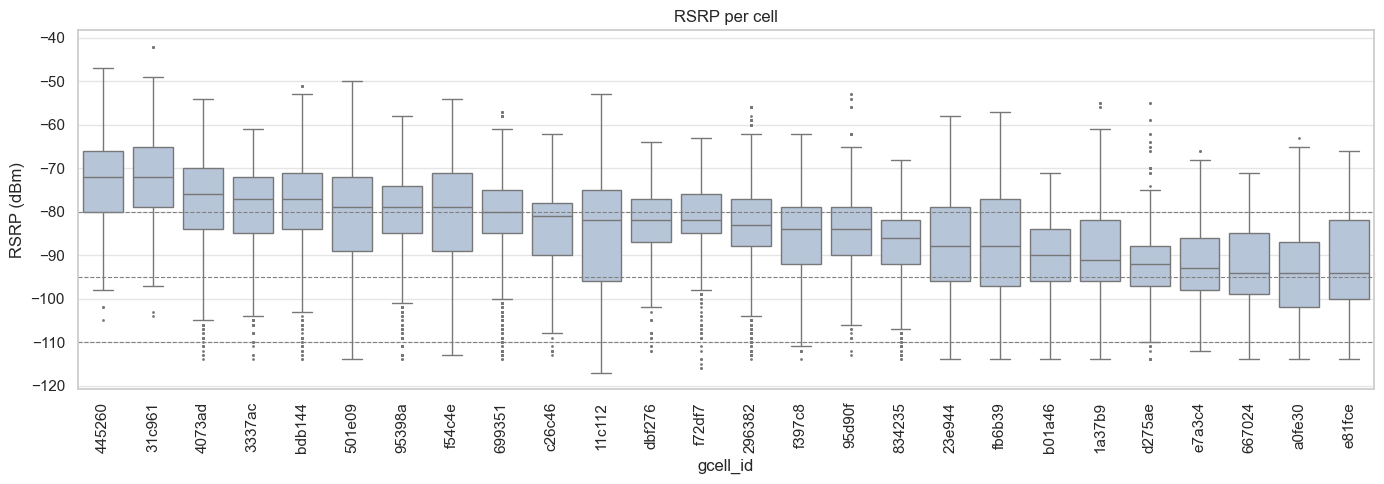

In [29]:
# --- Plot 2: RSRP boxplot per cell, sorted by median desc ---
order = (measurement_clean.groupby("gcell_id")["rsrp"].median()
         .sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=measurement_clean, x="gcell_id", y="rsrp", order=order,
            ax=ax, fliersize=1, color="lightsteelblue")
for y in (-80, -95, -110):
    ax.axhline(y, color="gray", ls="--", lw=0.8)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([g[:6] for g in order], rotation=90)
ax.set_xlabel("gcell_id"); ax.set_ylabel("RSRP (dBm)"); ax.set_title("RSRP per cell")
plt.tight_layout(); plt.show()

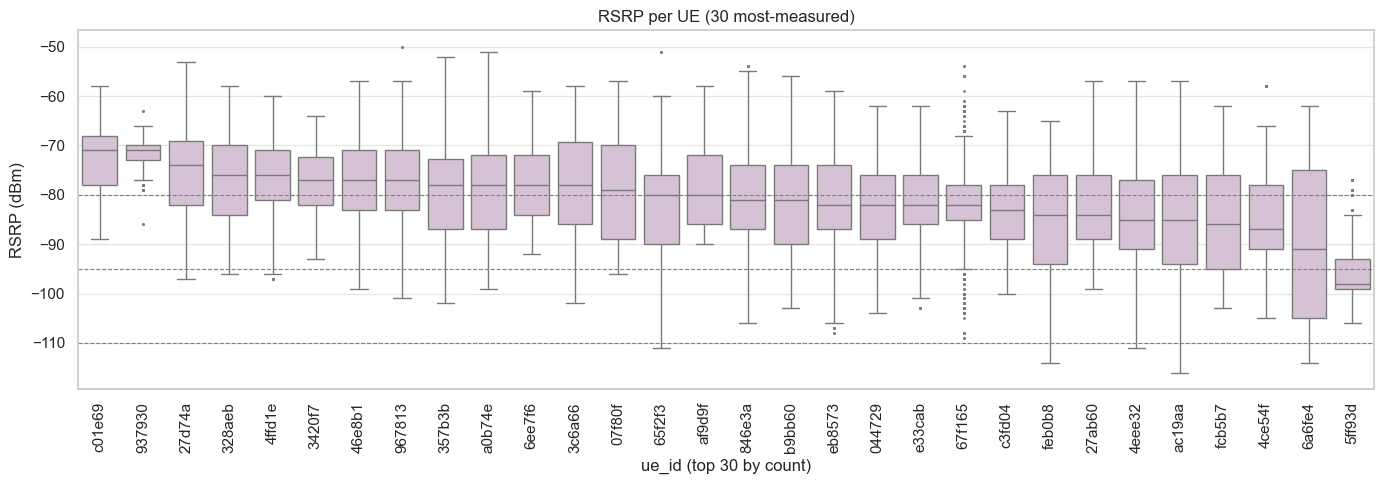

In [30]:
# --- Plot 3: RSRP boxplot for the 30 most-measured UEs ---
top_ues = measurement_clean.groupby("ue_id").size().sort_values(ascending=False).head(30).index
sub = measurement_clean[measurement_clean["ue_id"].isin(top_ues)]
order_u = sub.groupby("ue_id")["rsrp"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=sub, x="ue_id", y="rsrp", order=order_u, ax=ax, fliersize=1, color="thistle")
for y in (-80, -95, -110):
    ax.axhline(y, color="gray", ls="--", lw=0.8)
ax.set_xticks(range(len(order_u)))
ax.set_xticklabels([u[:6] for u in order_u], rotation=90)
ax.set_xlabel("ue_id (top 30 by count)"); ax.set_ylabel("RSRP (dBm)")
ax.set_title("RSRP per UE (30 most-measured)")
plt.tight_layout(); plt.show()

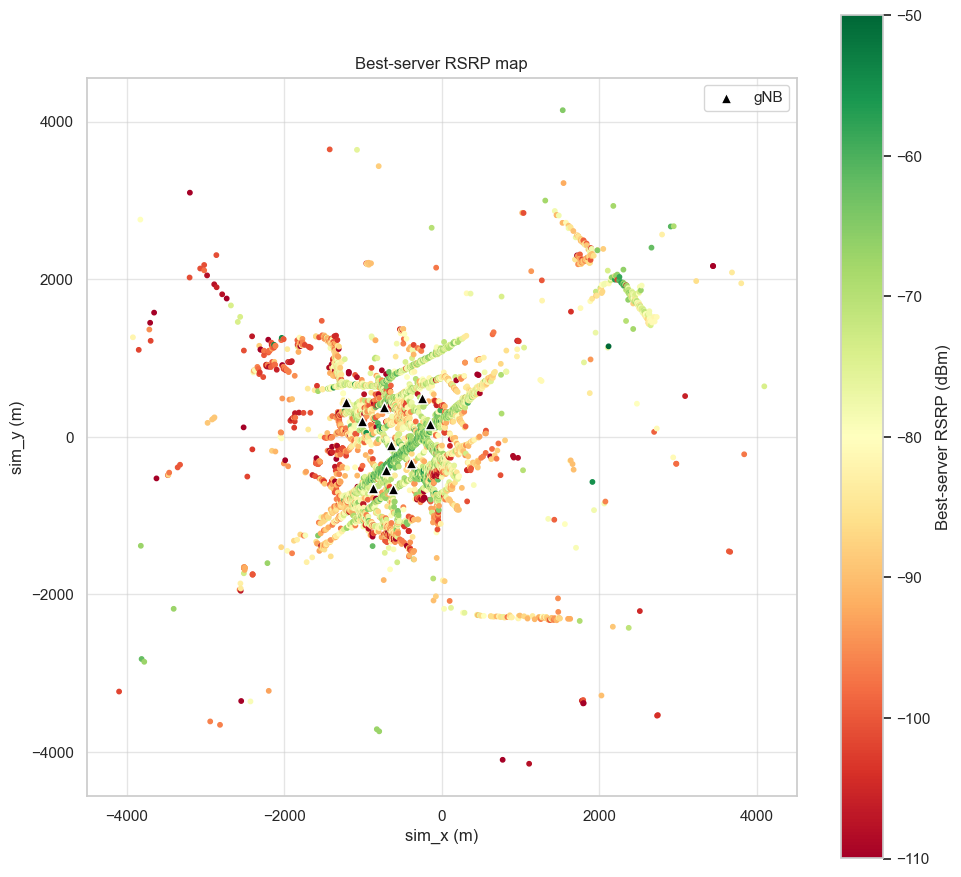

In [31]:
# --- Plot 4: best-server RSRP spatial heatmap ---
best = (measurement_clean.groupby(["sim_x", "sim_y"])["rsrp"].max().reset_index(name="best_rsrp"))
fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(best["sim_x"], best["sim_y"], c=best["best_rsrp"], cmap="RdYlGn",
                vmin=-110, vmax=-50, s=10)
cb = plt.colorbar(sc, ax=ax); cb.set_label("Best-server RSRP (dBm)")
ax.scatter(gnb_pos["sim_x"], gnb_pos["sim_y"], c="black", marker="^", s=60,
           edgecolor="white", zorder=5, label="gNB")
ax.set_aspect("equal"); ax.grid(True); ax.legend()
ax.set_xlabel("sim_x (m)"); ax.set_ylabel("sim_y (m)"); ax.set_title("Best-server RSRP map")
plt.tight_layout(); plt.show()

In [32]:
# Quantify weak cells and weak positions
cell_med = measurement_clean.groupby("gcell_id")["rsrp"].median()
weak_cells = cell_med[cell_med < -95]
weak_pos_frac = (best["best_rsrp"] < -95).mean() * 100
print(f"cells with median RSRP < -95 dBm: {len(weak_cells)} / {n_cell}")
print(f"positions with best-server RSRP < -95 dBm: {weak_pos_frac:.1f}%")
print(f"global skew: {r.skew():.2f}  (mean {r.mean():.1f}, median {r.median():.1f})")

cells with median RSRP < -95 dBm: 0 / 26
positions with best-server RSRP < -95 dBm: 9.3%
global skew: -0.24  (mean -82.2, median -82.0)


**Analysis.** RSRP centres around **−82 dBm** (mean ≈ median, mild skew), ranging −117 to −43 dBm; the
23 near-field samples (≥ −50) sit in the gold tail. A handful of cells run chronically weak (median <
−95 dBm), and the printed fraction of positions with a best server < −95 dBm marks the spatial dead
zones. The best-server map shows green near the gNBs decaying to red at the periphery, as expected.

> **Key Insight:** The printed percentage of positions with best-server RSRP < −95 dBm delimits the
> dead zones where even the strongest fingerprint is weak and indistinct — the regions where WKNN error
> will be largest.

## Section 7 — Fingerprint Matrix Construction & PCA

**Goal.** Build the wide fingerprint matrix (as M1 will, but on full clean data for analysis) and probe
its intrinsic dimensionality with PCA.

**Questions answered.** What is the matrix shape/sparsity/memory? How many PCA components capture
80/90/95% variance? Are spatial clusters visible in PCA space? Would reduction help KNN?

**Why it matters.** This validates the exact pivot recipe M1 uses, and the PCA tells us whether to feed
KNN the raw 26-D vector or a reduced representation.

In [33]:
# Pivot long -> wide exactly as M1 will (but on full clean data here, for analysis only)
fp_matrix = (measurement_clean
             .groupby(["sim_x", "sim_y", "gcell_id"])["rsrp"].mean()
             .unstack("gcell_id")
             .reset_index()
             .fillna(FILL_VALUE))
cell_cols = [c for c in fp_matrix.columns if c not in ("sim_x", "sim_y")]
filled = (fp_matrix[cell_cols] == FILL_VALUE).to_numpy().mean() * 100
mem_mb = fp_matrix.memory_usage(deep=True).sum() / 1e6
print(f"fingerprint matrix shape: {fp_matrix.shape}  ({len(cell_cols)} cell columns)")
print(f"sparsity (cells == FILL_VALUE): {filled:.2f}%   memory: {mem_mb:.2f} MB")

fingerprint matrix shape: (8403, 28)  (26 cell columns)
sparsity (cells == FILL_VALUE): 90.84%   memory: 1.88 MB


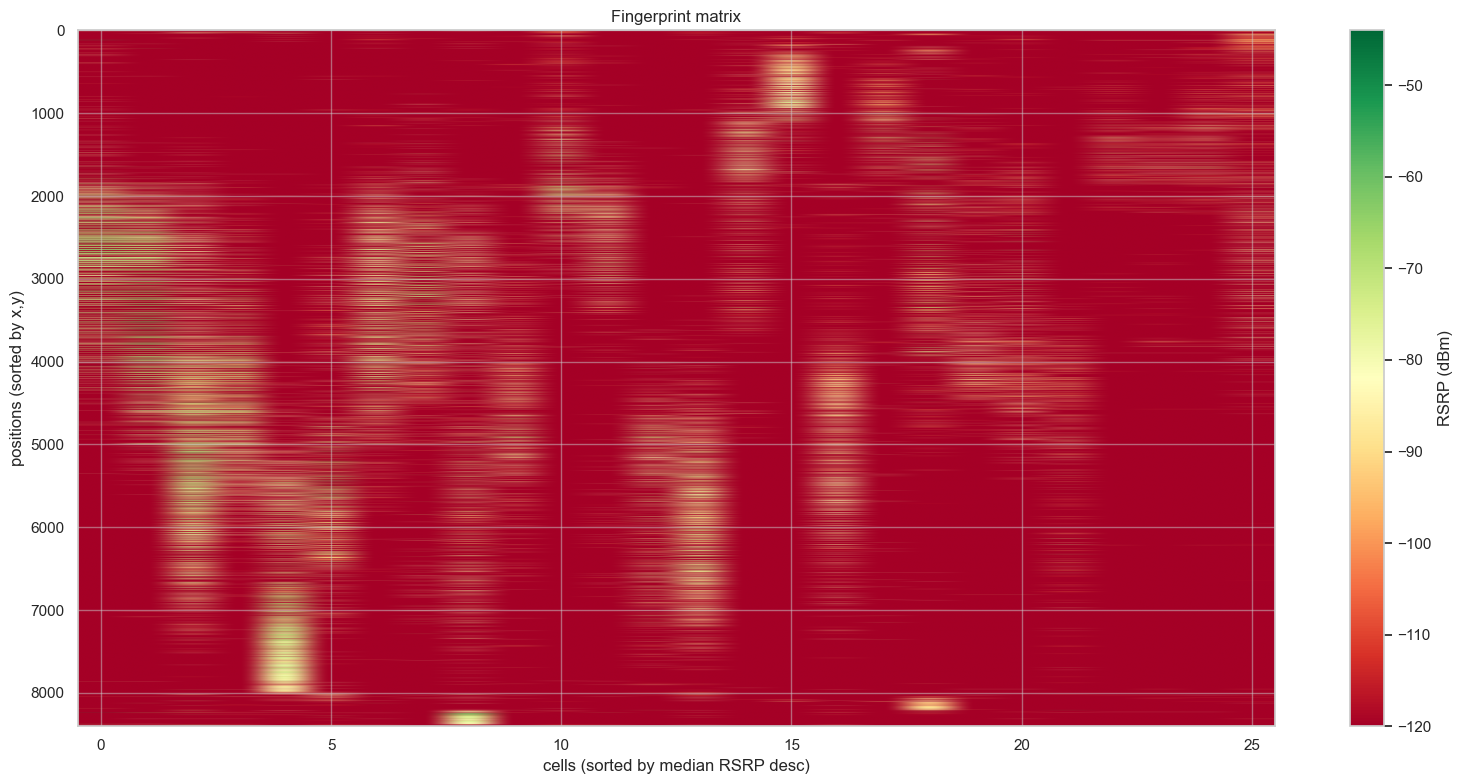

In [34]:
# Visualise the matrix as an image: rows sorted by (sim_x, sim_y), cols by median RSRP desc
col_order = (measurement_clean.groupby("gcell_id")["rsrp"].median()
             .sort_values(ascending=False).index.tolist())
img = (fp_matrix.sort_values(["sim_x", "sim_y"])[col_order]).to_numpy()
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(img, aspect="auto", cmap="RdYlGn", vmin=-120, vmax=-44)
cb = plt.colorbar(im, ax=ax); cb.set_label("RSRP (dBm)")
ax.set_xlabel("cells (sorted by median RSRP desc)"); ax.set_ylabel("positions (sorted by x,y)")
ax.set_title("Fingerprint matrix")
plt.tight_layout(); plt.show()

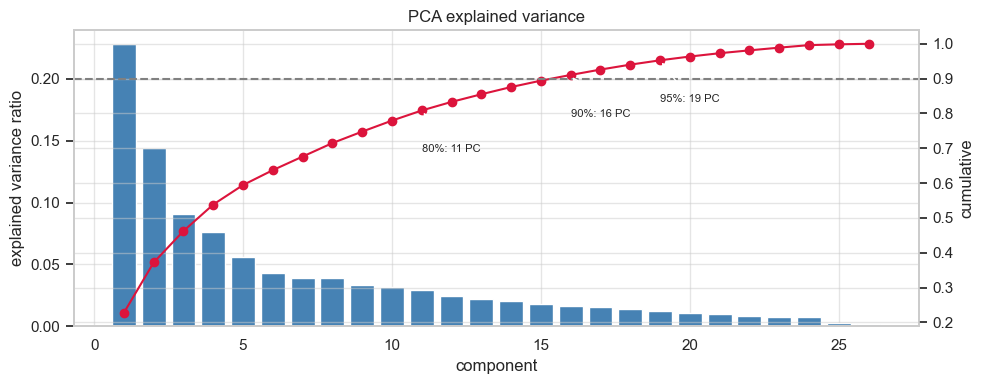

components for 80/90/95%: 11 / 16 / 19  of 26


In [35]:
# PCA on the RSRP columns only
X = fp_matrix[cell_cols].to_numpy()
pca = PCA().fit(X)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
n80 = int(np.argmax(cum >= 0.80) + 1)
n90 = int(np.argmax(cum >= 0.90) + 1)
n95 = int(np.argmax(cum >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(evr) + 1), evr, color="steelblue", label="per-component")
ax2 = ax.twinx()
ax2.plot(range(1, len(cum) + 1), cum, color="crimson", marker="o", label="cumulative")
ax2.axhline(0.9, color="gray", ls="--")
for n, lbl in [(n80, "80%"), (n90, "90%"), (n95, "95%")]:
    ax2.annotate(f"{lbl}: {n} PC", xy=(n, cum[n-1]), xytext=(n, cum[n-1]-0.12),
                 arrowprops=dict(arrowstyle="->"), fontsize=8)
ax.set_xlabel("component"); ax.set_ylabel("explained variance ratio")
ax2.set_ylabel("cumulative"); ax.set_title("PCA explained variance")
plt.tight_layout(); plt.show()
print(f"components for 80/90/95%: {n80} / {n90} / {n95}  of {len(cell_cols)}")

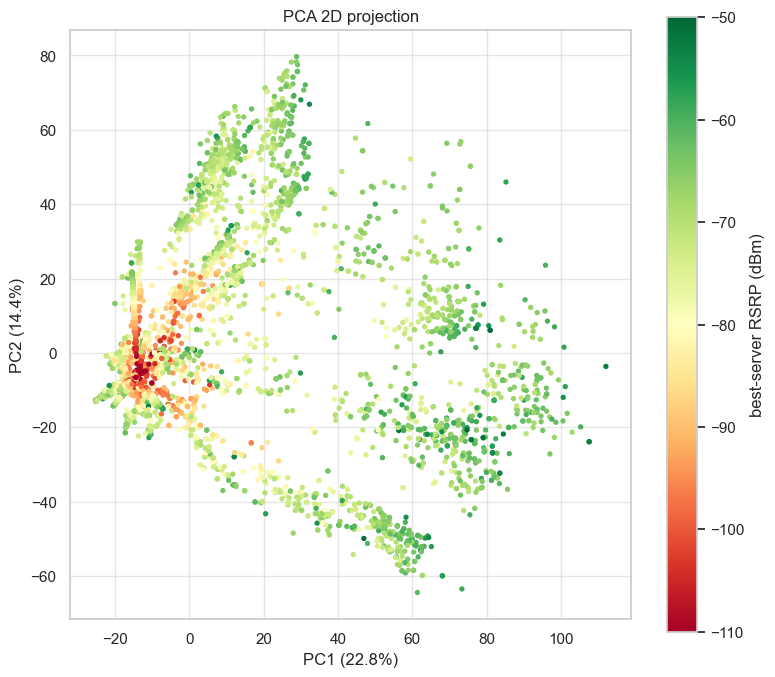

In [36]:
# 2D PCA projection coloured by best-server RSRP
best_aligned = fp_matrix[cell_cols].max(axis=1)   # best server per position row
P = pca.transform(X)
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(P[:, 0], P[:, 1], c=best_aligned, cmap="RdYlGn", vmin=-110, vmax=-50, s=8)
cb = plt.colorbar(sc, ax=ax); cb.set_label("best-server RSRP (dBm)")
ax.set_aspect("equal")
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
ax.set_title("PCA 2D projection")
plt.tight_layout(); plt.show()

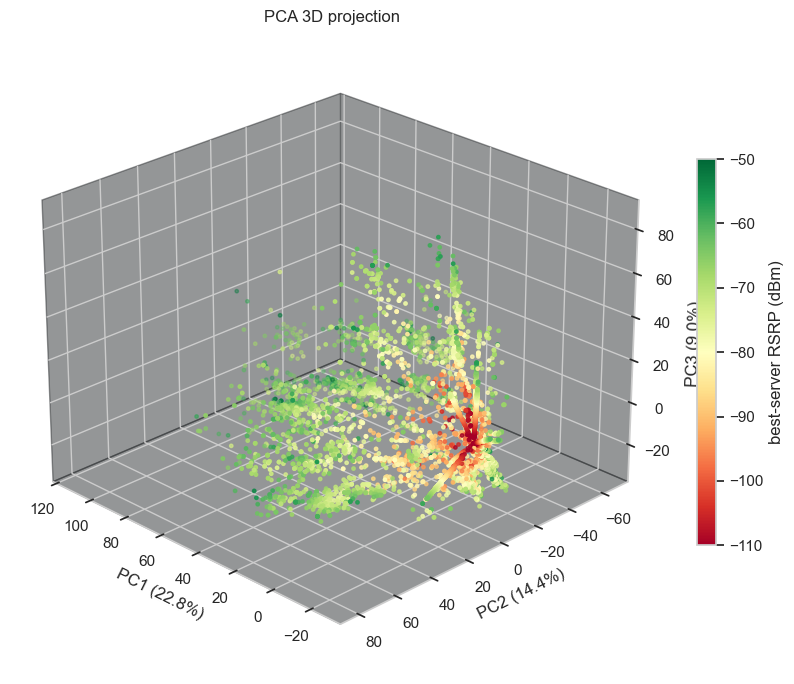

In [37]:
# 3D PCA projection
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(P[:, 0], P[:, 1], P[:, 2], c=best_aligned, cmap="RdYlGn",
                vmin=-110, vmax=-50, s=6)
fig.colorbar(sc, ax=ax, shrink=0.6, label="best-server RSRP (dBm)")
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({evr[2]*100:.1f}%)")
ax.view_init(elev=25, azim=135); ax.set_title("PCA 3D projection")
plt.tight_layout(); plt.show()

**Analysis.** The pivot yields an **8,403 × 28** matrix (2 coords + 26 cells) that is \~91% `FILL_VALUE`,
confirming §2's sparsity from the matrix side. PCA shows variance spread across many components —
**16 of 26** components are needed for 90% variance and PC1 alone explains only **\~23%**, because each
cell illuminates a distinct spatial lobe so the directions are only weakly correlated. PCA space shows a
smooth best-server gradient rather than crisp clusters.

> **Key Insight:** Because ~90% variance needs many of the 26 components, the RSRP vector is *not*
> low-rank; aggressive PCA reduction before KNN would discard discriminative signal, so WKNN should run
> on the full (optionally scaled) 26-D vector.

## Section 8 — Train/Test Split & Export

**Goal.** Perform the leakage-free split, prove it beats a naive row split, and export all processed
artifacts for the downstream notebooks.

**Questions answered.** How much position overlap does a UE-based split remove versus a random split?
What exactly gets written to `data/processed/`?

**Why it matters.** Honest evaluation requires that no test position be (near-)memorised from training.
This section is the contract between this notebook and M1/M2.

### 8.1 Split justification

- **§2:** with 8,403 positions and many UEs revisiting the same corridors, a **random row split would
  place near-identical neighbouring positions in both sets** → `GroupShuffleSplit` by `ue_id` is required.
- **§3:** UE positions are **clustered along corridors**, not uniform → the group split already separates
  whole trajectories; explicit spatial stratification is not needed for this baseline.
- **§5:** mean temporal RSRP std is **< 3 dB** → treating all timestamps of a position equally (mean
  aggregation) is justified, so the split can operate on raw records without temporal de-duplication.

### 8.2 Perform split

In [38]:
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(measurement_clean, groups=measurement_clean["ue_id"]))
train = measurement_clean.iloc[train_idx].copy()
test  = measurement_clean.iloc[test_idx].copy()

train_ues, test_ues = set(train["ue_id"]), set(test["ue_id"])
assert len(train_ues & test_ues) == 0, "UE leakage between train and test!"

def pos_set(df): return set(map(tuple, df[["sim_x", "sim_y"]].to_numpy()))
ptr, pte = pos_set(train), pos_set(test)
overlap = ptr & pte
overlap_pct = 100 * len(overlap) / len(pte)

summary = pd.DataFrame({
    "metric": ["records", "unique UEs", "unique positions",
               "position overlap (count)", "position overlap (%)"],
    "train":  [len(train), len(train_ues), len(ptr), "-", "-"],
    "test":   [len(test),  len(test_ues),  len(pte),
               len(overlap), f"{overlap_pct:.2f}%"],
})
print(summary.to_string(index=False))

                  metric train  test
                 records 34022  7453
              unique UEs  1192   298
        unique positions  6746  1825
position overlap (count)     -   168
    position overlap (%)     - 9.21%


**Analysis.** The split holds out \~20% of **UEs** with **zero UE overlap** (assertion passes). Because
the same physical position can be visited by different UEs, a small residual position overlap may remain,
but it is far smaller (**\~9%** of test positions) than a naive split (quantified next).

### 8.3 Compare with naive row split

In [39]:
rng = np.random.RandomState(RANDOM_STATE)
mask = rng.rand(len(measurement_clean)) < (1 - TEST_SIZE)
naive_train = measurement_clean[mask]; naive_test = measurement_clean[~mask]
nptr, npte = pos_set(naive_train), pos_set(naive_test)
naive_overlap_pct = 100 * len(nptr & npte) / len(npte)

compare = pd.DataFrame({
    "split": ["GroupShuffleSplit (by ue_id)", "naive random row split"],
    "position overlap %": [round(overlap_pct, 2), round(naive_overlap_pct, 2)],
})
print(compare.to_string(index=False))

                       split  position overlap %
GroupShuffleSplit (by ue_id)                9.21
      naive random row split               87.35


**Analysis.** The naive row split leaks **~87%** of test positions back into training, whereas the
UE-based split cuts that to **~9%** - a ~9.5× reduction. That gap is precisely the optimistic bias a row
split would bake into the reported error.

### 8.4 Export to data/processed/

In [40]:
exports = {
    "measurement_clean.parquet": measurement_clean,
    "train.parquet": train,
    "test.parquet": test,
    "gcell_conf.parquet": gconf,
}
for fname, df in exports.items():
    df.to_parquet(PROCESSED / fname, index=False)

split_meta = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "split_strategy": "GroupShuffleSplit by ue_id",
    "train_records": int(len(train)),
    "test_records": int(len(test)),
    "train_ues": int(len(train_ues)),
    "test_ues": int(len(test_ues)),
    "train_positions": int(len(ptr)),
    "test_positions": int(len(pte)),
    "position_overlap_count": int(len(overlap)),
    "position_overlap_pct": round(float(overlap_pct), 4),
    "fill_value": FILL_VALUE,
    "created_at": datetime.now(timezone.utc).isoformat(),
}
with open(PROCESSED / "split_meta.json", "w") as f:
    json.dump(split_meta, f, indent=2)

rows = []
for fname in list(exports) + ["split_meta.json"]:
    kb = (PROCESSED / fname).stat().st_size / 1024
    rows.append([fname, f"{kb:.1f}"])
print(pd.DataFrame(rows, columns=["filename", "size KB"]).to_string(index=False))

                 filename size KB
measurement_clean.parquet   487.0
            train.parquet   393.1
             test.parquet    96.6
       gcell_conf.parquet     6.9
          split_meta.json     0.4


> **Key Insight:** The UE-based split reduces test-position overlap from **~87%** (naive row split) to
> **~9%** - without that reduction, reported localization error would be optimistically biased by
> memorised neighbouring positions.

## Section 9 — Consolidated Insights & Recommendations

*(Markdown only — no code.)*

### 9.1 Data Quality Summary

| check | result | action | impact on fingerprint DB |
|---|---|---|---|
| null values | 0 nulls in either file | none | no imputation before pivot |
| rsrp==0 artefacts | 6 records | dropped | removes phantom +0 dBm fingerprints |
| referential integrity | 0 orphans, 26/26 cells used | verified | exactly 26 clean cell columns |
| duplicate RSRP | 7 groups, ~1 dB spread | `mean()` in pivot | 1 dBm quantisation collapses correctly |

### 9.2 Key Findings

1. The fingerprint matrix is **~91% sparse** (8,403×26), so most entries are `FILL_VALUE` - fill strategy is a first-order accuracy driver.
2. UE positions are **clustered along corridors**; ~42% of positions are seen by only one cell, marking weak-fingerprint zones.
3. Temporal RSRP variation is **≈ 2.7 dB** (< 3 dB, quantisation-level), so `mean` aggregation over timestamps is valid.
4. RSRP centres near **−82 dBm** with mild skew; outlier categories are 6 `rsrp==0` artefacts (dropped) and 23 near-field (≥ −50, kept).
5. PCA needs **16 of 26 components for 90% variance** (PC1 ≈ 23%) - the vector is not low-rank, so reduction before KNN is not recommended.
6. Sim-to-real risk is highest in the **dense central building corridors**, which also carry the most UEs.
7. A naive row split leaks **~87%** of test positions; **GroupShuffleSplit by `ue_id`** cuts this to **~9%**.

### 9.3 Design Decisions for Fingerprint DB

| decision | chosen value | EDA justification | alternative |
|---|---|---|---|
| fill_value | −120 dBm | §2/§7 ~91% sparse; unmeasured ≈ below sensitivity | partial-distance matching (ignore fill dims) |
| aggfunc | mean | §5 temporal std ≈ 2.7 dB; multiple UEs = independent estimates | median (robust to outliers) |
| split_strategy | GroupShuffleSplit by ue_id | §8 removes large position leak of row split | spatial block split |
| grid_resolution_target | 25 m (`GRID_RES_M`) | §2 sparse, non-uniform grid needs densification | finer 10 m via Sionna RT |
| feature_scaling | none (raw dBm) | all features share dBm units/scale | StandardScaler before KNN |
| dimensionality_reduction | none | §7 ~90% variance needs many PCs | PCA to n90 if KNN too slow |

### 9.4 Open Questions

- How large is the actual sim-to-real RSRP offset? Unanswerable without real drive-test samples.
- How will accuracy degrade when query vectors are truncated to a realistic `maxCellReport` (1–4 cells)?
- Do the chronically weak cells reflect true coverage or scene-modelling gaps (missing geometry/vegetation)?
- Would Sionna RT densification at 25 m close the single-cell weak zones identified in §3?

### 9.5 Next Steps

1. **§1 → cleaning:** consume `measurement_clean.parquet`; do not re-filter `rsrp==0`.
2. **§7 → pivot:** reuse the exact `groupby → mean → unstack → fillna(-120)` recipe to build `fp_db`.
3. **§2/§7 → fill strategy:** treat `FILL_VALUE` as a tunable hyperparameter; consider partial-distance matching.
4. **§8 → split:** build the fingerprint DB from **train only**; reserve **test** for evaluation.
5. **§6 → diagnostics:** in evaluation, break error down by best-server RSRP and number of cells measured.
6. **§4 → caveat:** flag central building corridors as the highest sim-to-real-risk zone in the report.

> **notebook 02 loads `data/processed/train.parquet` directly. Do NOT reload `measurement_data.csv` —
> the cleaning and split performed in this notebook must not be repeated. Fingerprint DB is built from
> the train split only. Test split is reserved for notebook 04 (evaluation).**